# Análisis Exploratorio y Detección de Anomalías — Salud Pública Ecuador (2023-2024)

**Proyecto:** Análisis de Datos — EPN, 2026-A
**Fuente de datos:** Data Warehouse en SQL Server (`sqlServer_warehouse`), cargado desde el pipeline ETL de KNIME.

1. Conexión al Data Warehouse (o carga alternativa desde CSV exportado).
2. Análisis exploratorio de datos (EDA): distribuciones, tendencias por provincia/mes, top de diagnósticos.
3. Técnica alternativa de análisis avanzado — **detección de anomalías con Isolation Forest**(ya que no hay texto para analizar sentimiento)
4. Uso de Redis/Valkey como caché de lookup rápido para nombres de diagnósticos CIE-10.

In [1]:
# 1. Dependencias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [2]:
# 2. Configuración de conexión al Data Warehouse (SQL Server)
import getpass

DB_SERVER   = "localhost"
DB_NAME     = "datawarehouse_salud"
DB_USER     = "sa"
DB_PASSWORD = getpass.getpass("Contraseña de SQL Server: ")  
DB_DRIVER   = "ODBC Driver 17 for SQL Server"

USE_DB = True   


## 3. Carga de datos vía SQL Server 

In [3]:

if USE_DB:
    from sqlalchemy import create_engine
    import urllib

    params = urllib.parse.quote_plus(
        f"DRIVER={{{DB_DRIVER}}};SERVER={DB_SERVER};DATABASE={DB_NAME};"
        f"UID={DB_USER};PWD={DB_PASSWORD}"
    )
    engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

    fact_emergencias = pd.read_sql("SELECT * FROM fact_emergencias", engine)
    dim_clima        = pd.read_sql("SELECT * FROM dim_clima", engine)
    dim_cie10        = pd.read_sql("SELECT * FROM dim_cie10", engine)
    dim_fecha        = pd.read_sql("SELECT * FROM dim_fecha", engine)
    fact_egresos     = pd.read_sql("SELECT * FROM fact_egresos", engine)

print(f"fact_emergencias: {len(fact_emergencias):,} filas")
print(f"fact_egresos: {len(fact_egresos):,} filas")


fact_emergencias: 1,945,520 filas
fact_egresos: 1,835,176 filas


## 3b. Validación de calidad de datos

Antes de unir las dimensiones con el hecho, se revisa cada tabla cargada: nulos, duplicados,
tipos de dato y tamaño. Esto detecta problemas de origen (ETL de KNIME) antes de que se
propaguen al resto del análisis.

In [4]:
llaves = {"fecha_id": (fact_emergencias, dim_fecha), "cie10_id": (fact_emergencias, dim_cie10)}

for llave, (hecho, dimension) in llaves.items():
    huerfanos = ~hecho[llave].isin(dimension[llave])
    print(f"{llave}: {huerfanos.sum():,} filas de fact_emergencias sin correspondencia en la dimensión "
        f"({huerfanos.mean()*100:.2f}%)")


fecha_id: 4,014 filas de fact_emergencias sin correspondencia en la dimensión (0.21%)
cie10_id: 391,740 filas de fact_emergencias sin correspondencia en la dimensión (20.14%)


## 4. Preparación de datos

Se enriquece `fact_emergencias` con las dimensiones necesarias para el EDA (fecha calendario, provincia ya viene en el hecho, nombre de diagnóstico).

In [5]:
# 4. Enriquecer emergencias con dim_fecha y dim_cie10 para tener columnas legibles
df = fact_emergencias.merge(
      dim_fecha, left_on="fecha_id", right_on="fecha_id", how="left", suffixes=("", "_fecha")
   ).merge(
      dim_cie10, left_on="cie10_id", right_on="cie10_id", how="left", suffixes=("", "_cie10")
   )

print(df.columns.tolist())
df.head()


['UNICODIGO', 'ESTABLECIMIENTO', 'PROVINCIA', 'FECHA_DE_ATENCION', 'SEXO', 'EDAD', 'NACIONALIDAD', 'CIE', 'DIAGNOSTICO', 'codigo_cie10', 'categoria_cie10', 'nivel', 'categoria_calculada', 'cie10_id', 'fecha_id', 'temperatura_promedio', 'lluvia_total_mm', 'condicion_clima', 'clima_id', 'Date', 'Year', 'Month (Name)', 'Day of Month', 'Day of Week (Name)', 'Quarter', 'codigo_cie10_cie10', 'nombre_enfermedad', 'categoria_cie10_cie10', 'nivel_cie10', 'categoria_calculada_cie10']


,UNICODIGO,ESTABLECIMIENTO,PROVINCIA,FECHA_DE_ATENCION,SEXO,EDAD,NACIONALIDAD,CIE,DIAGNOSTICO,codigo_cie10,categoria_cie10,nivel,categoria_calculada,cie10_id,fecha_id,temperatura_promedio,lluvia_total_mm,condicion_clima,clima_id,Date,Year,Month (Name),Day of Month,Day of Week (Name),Quarter,codigo_cie10_cie10,nombre_enfermedad,categoria_cie10_cie10,nivel_cie10,categoria_calculada_cie10
0,4017,Centro De Salud Tipo C Las Palmas,ESMERALDAS,2024-03-18,Mujer,23,Ecuatoriano/a,A590,TRICOMONIASIS UROGENITAL,A590,Ciertas enfermedades infecciosas y parasitarias,subcategoria,A59,309.0,442.0,26.6,2.4,Lluvia Ligera,5560.0,2024-03-18,2024.0,marzo,18.0,lunes,1.0,A590,Tricomoniasis urogenital,Ciertas enfermedades infecciosas y parasitarias,subcategoria,A59
1,710,Hospital Basico Alberto Buffonny,ESMERALDAS,2024-03-18,Mujer,28,Ecuatoriano/a,O235,INFECCION GENITAL EN EL EMBARAZO,O235,O23,subcategoria,O23,6525.0,442.0,26.6,2.4,Lluvia Ligera,5560.0,2024-03-18,2024.0,marzo,18.0,lunes,1.0,O235,Infección genital en el embarazo,O23,subcategoria,O23
2,4017,Centro De Salud Tipo C Las Palmas,ESMERALDAS,2024-03-18,Hombre,2,Ecuatoriano/a,R500,FIEBRE CON ESCALOFRIO,R500,"Síntomas, signos y hallazgos anormales clínico...",subcategoria,R50,8163.0,442.0,26.6,2.4,Lluvia Ligera,5560.0,2024-03-18,2024.0,marzo,18.0,lunes,1.0,R500,Fiebre con escalofrio,"Síntomas, signos y hallazgos anormales clínico...",subcategoria,R50
3,714,Hospital Basico Dr. Carlos Del Pozo Melgar,ESMERALDAS,2024-03-18,Mujer,1,Ecuatoriano/a,K529,"COLITIS Y GASTROENTERITIS NO INFECCIOSAS, NO E...",K529,Enfermedades del sistema digestivo,subcategoria,K52,4659.0,442.0,26.6,2.4,Lluvia Ligera,5560.0,2024-03-18,2024.0,marzo,18.0,lunes,1.0,K529,"Colitis y gastroenteritis no infecciosas, no e...",Enfermedades del sistema digestivo,subcategoria,K52
4,710,Hospital Basico Alberto Buffonny,ESMERALDAS,2024-03-18,Mujer,7,Ecuatoriano/a,T784,ALERGIA NO ESPECIFICADA,T784,"Traumatismos, envenenamientos y algunas otras ...",subcategoria,T78,9664.0,442.0,26.6,2.4,Lluvia Ligera,5560.0,2024-03-18,2024.0,marzo,18.0,lunes,1.0,T784,Alergia no especificada,"Traumatismos, envenenamientos y algunas otras ...",subcategoria,T78


## 4b. Limpieza avanzada y validación de calidad del dataset enriquecido (`df`)

Con `df` ya construido, aplicamos las reglas de negocio para detectar y
corregir valores inválidos antes de usar `df` en el EDA y el modelo de anomalías: duplicados,
edades fuera de rango, campos categóricos con inconsistencias de formato y fechas fuera del
periodo del estudio.

In [6]:
#Duplicados exactos y por llave natural
print(f"Duplicados exactos en df: {df.duplicated().sum():,}")

llave_natural = ["fecha_id", "cie10_id", "PROVINCIA", "EDAD", "SEXO"]
llave_natural = [c for c in llave_natural if c in df.columns]
if llave_natural:
    print(f"Duplicados por llave natural {llave_natural}: {df.duplicated(subset=llave_natural).sum():,}")

df = df.drop_duplicates()


Duplicados exactos en df: 16,628
Duplicados por llave natural ['fecha_id', 'cie10_id', 'PROVINCIA', 'EDAD', 'SEXO']: 186,036


In [7]:
#Validación de rangos: edad y fechas fuera de lo plausible
n_antes = len(df)

edad_invalida = ~df["EDAD"].between(0, 110)
print(f"Registros con EDAD fuera de [0, 110]: {edad_invalida.sum():,}")

if "Date" in df.columns:
    fecha_col = pd.to_datetime(df["Date"], errors="coerce")
    fecha_invalida = fecha_col.isna() | ~fecha_col.dt.year.between(2023, 2024)
    print(f"Registros con fecha faltante o fuera de 2023-2024: {fecha_invalida.sum():,}")
else:
    fecha_invalida = pd.Series(False, index=df.index)

# Se descartan filas con edad o fecha inválidas
df = df[~edad_invalida & ~fecha_invalida].copy()
print(f"Filas descartadas por reglas de calidad: {n_antes - len(df):,} de {n_antes:,}")


Registros con EDAD fuera de [0, 110]: 0
Registros con fecha faltante o fuera de 2023-2024: 3,985
Filas descartadas por reglas de calidad: 3,985 de 1,928,892


## 5. Análisis exploratorio (EDA)

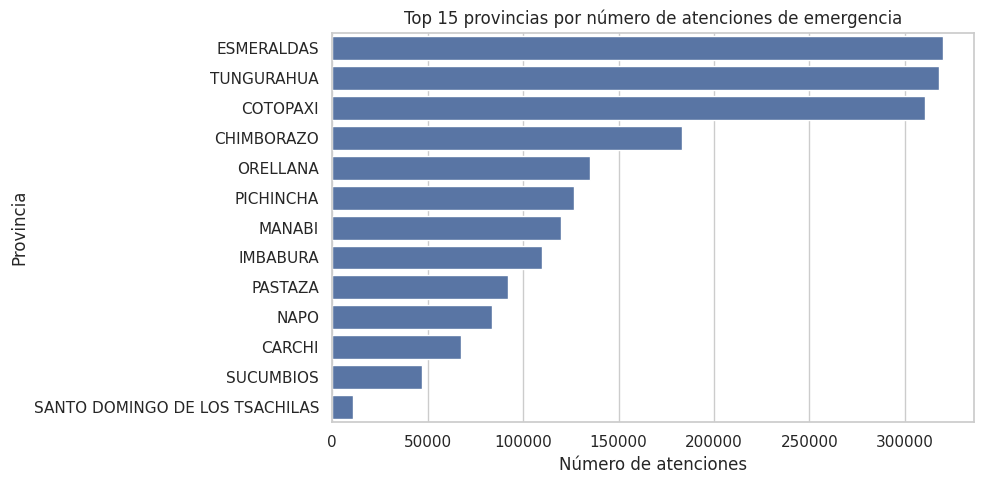

In [8]:
# 5.1 Distribución de atenciones por provincia
top_provincias = df["PROVINCIA"].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_provincias.values, y=top_provincias.index, color="#4C72B0")
plt.title("Top 15 provincias por número de atenciones de emergencia")
plt.xlabel("Número de atenciones")
plt.ylabel("Provincia")
plt.tight_layout()
plt.savefig("output_top_provincias.png", dpi=150)
plt.show()


In [ ]:
# 5.1b Valores exactos de atenciones por provincia 
print(top_provincias)


PROVINCIA
ESMERALDAS                        320250
TUNGURAHUA                        318021
COTOPAXI                          310836
CHIMBORAZO                        183502
ORELLANA                          135284
PICHINCHA                         126861
MANABI                            119650
IMBABURA                          109818
PASTAZA                            92064
NAPO                               83596
CARCHI                             67383
SUCUMBIOS                          47023
SANTO DOMINGO DE LOS TSACHILAS     10619
Name: count, dtype: int64


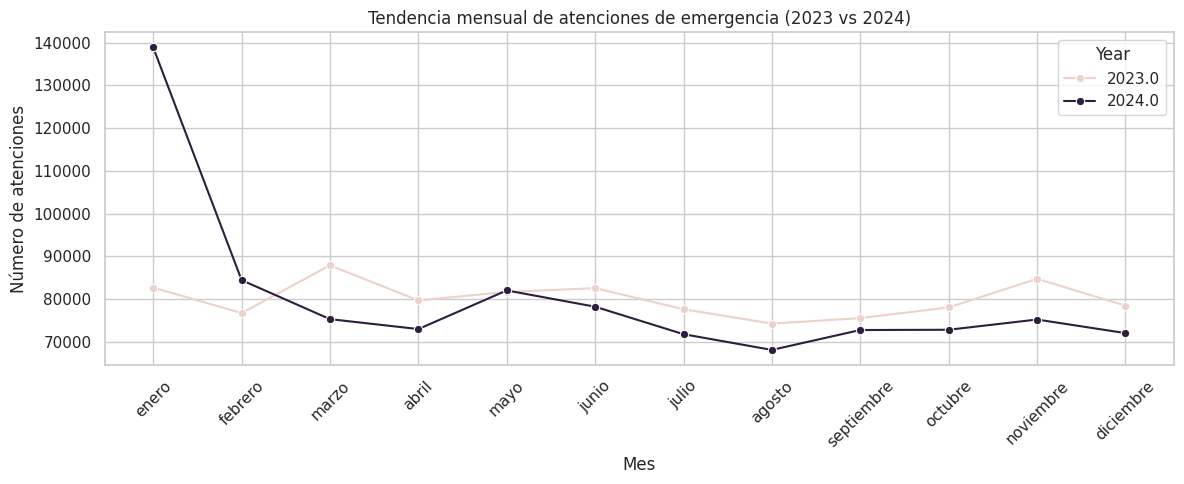

In [10]:
# 5.2 Tendencia mensual de atenciones
tendencia = df.groupby(["Year", "Month (Name)"]).size().reset_index(name="atenciones")

# Orden de meses para que el gráfico no salga alfabético
orden_meses = ["enero","febrero","marzo","abril","mayo","junio",
            "julio","agosto","septiembre","octubre","noviembre","diciembre"]
tendencia["Month (Name)"] = pd.Categorical(tendencia["Month (Name)"].str.lower(), categories=orden_meses, ordered=True)
tendencia = tendencia.sort_values(["Year", "Month (Name)"])

plt.figure(figsize=(12, 5))
sns.lineplot(data=tendencia, x="Month (Name)", y="atenciones", hue="Year", marker="o")
plt.title("Tendencia mensual de atenciones de emergencia (2023 vs 2024)")
plt.xlabel("Mes")
plt.ylabel("Número de atenciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output_tendencia_mensual.png", dpi=150)
plt.show()

In [ ]:
# 5.2b Tabla exacta de atenciones por mes y año
tabla_tendencia = tendencia.pivot(index="Month (Name)", columns="Year", values="atenciones")
print(tabla_tendencia)


Year          2023.0  2024.0
Month (Name)                
enero          82704  138888
febrero        76753   84448
marzo          87910   75324
abril          79698   73003
mayo           81694   82041
junio          82575   78231
julio          77643   71805
agosto         74279   68125
septiembre     75566   72779
octubre        78063   72839
noviembre      84760   75233
diciembre      78485   72061


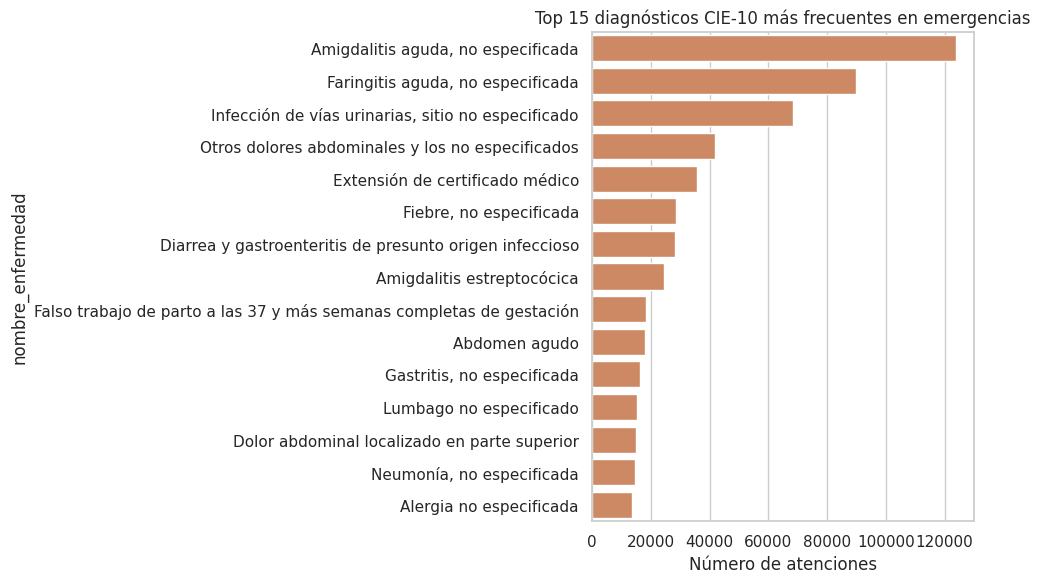

In [12]:
# 5.3 Top diagnósticos CIE-10 más frecuentes
top_diagnosticos = df["nombre_enfermedad"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_diagnosticos.values, y=top_diagnosticos.index, color="#DD8452")
plt.title("Top 15 diagnósticos CIE-10 más frecuentes en emergencias")
plt.xlabel("Número de atenciones")
plt.tight_layout()
plt.savefig("output_top_diagnosticos.png", dpi=150)
plt.show()


In [ ]:
# 5.3b Valores exactos de los diagnósticos más frecuentes
print(top_diagnosticos)


nombre_enfermedad
Amigdalitis aguda, no especificada                                      123824
Faringitis aguda, no especificada                                        89832
Infección de vías urinarias, sitio no especificado                       68473
Otros dolores abdominales y los no especificados                         41804
Extensión de certificado médico                                          35629
Fiebre, no especificada                                                  28646
Diarrea y gastroenteritis de presunto origen infeccioso                  28221
Amigdalitis estreptocócica                                               24471
Falso trabajo de parto a las 37 y más semanas completas de gestación     18440
Abdomen agudo                                                            18059
Gastritis, no especificada                                               16380
Lumbago no especificado                                                  15104
Dolor abdominal localizado en part

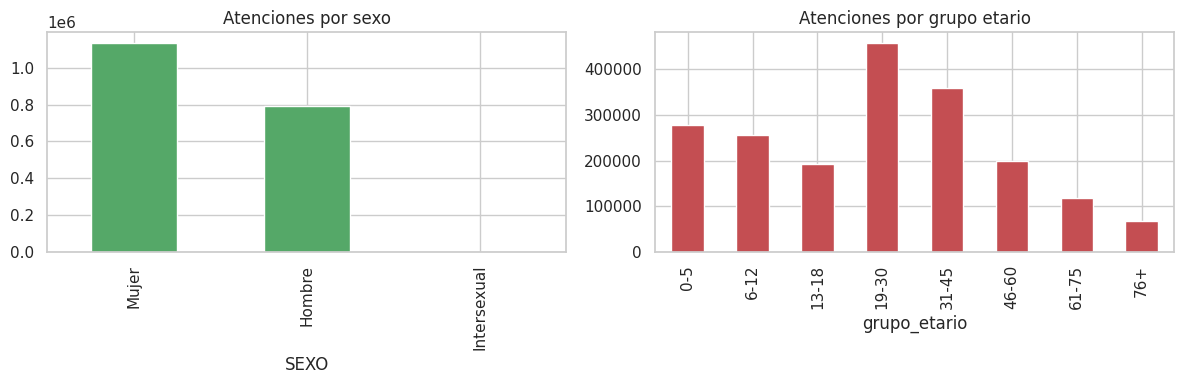

In [14]:
# 5.4 Distribución por sexo y grupo etario
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["SEXO"].value_counts().plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Atenciones por sexo")

bins = [0, 5, 12, 18, 30, 45, 60, 75, 110]
labels = ["0-5", "6-12", "13-18", "19-30", "31-45", "46-60", "61-75", "76+"]
df["grupo_etario"] = pd.cut(df["EDAD"], bins=bins, labels=labels, right=True)
df["grupo_etario"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Atenciones por grupo etario")

plt.tight_layout()
plt.savefig("output_sexo_edad.png", dpi=150)
plt.show()


In [ ]:
# 5.4b Valores exactos por sexo y grupo etario 
print(df["SEXO"].value_counts())
print()
print(df["grupo_etario"].value_counts().sort_index())


SEXO
Mujer          1135455
Hombre          789427
Intersexual         25
Name: count, dtype: int64

grupo_etario
0-5      277439
6-12     255232
13-18    193409
19-30    458142
31-45    358353
46-60    198323
61-75    117002
76+       66928
Name: count, dtype: int64


## 6. Detección de anomalías con Isolation Forest

Dado que el caso de estudio no contiene texto libre (no aplica análisis de sentimiento), se implementa una técnica alternativa de las sugeridas: **detección de anomalías**.

In [16]:
#6.1 Serie diaria de atenciones por provincia
df["fecha"] = pd.to_datetime(df["Date"])

serie_diaria = (
    df.groupby(["PROVINCIA", "fecha"]).size().reset_index(name="atenciones_dia")
)

serie_diaria.head()

,PROVINCIA,fecha,atenciones_dia
0,CARCHI,2023-01-01,109
1,CARCHI,2023-01-02,85
2,CARCHI,2023-01-03,95
3,CARCHI,2023-01-04,139
4,CARCHI,2023-01-05,75


In [17]:
#6.2 Isolation Forest por provincia (cada provincia tiene su propia escala de demanda)
resultados = []

for provincia, grupo in serie_diaria.groupby("PROVINCIA"):
    if len(grupo) < 30:
        continue  #pocos datos para esa provincia, se omite

    X = grupo[["atenciones_dia"]].values
    modelo = IsolationForest(contamination=0.03, random_state=42)
    grupo = grupo.copy()
    grupo["anomalia"] = modelo.fit_predict(X)  # -1 = anomalía, 1 = normal
    resultados.append(grupo)

serie_con_anomalias = pd.concat(resultados, ignore_index=True)
anomalias = serie_con_anomalias[serie_con_anomalias["anomalia"] == -1]

print(f"Total de días-provincia marcados como anomalía: {len(anomalias):,} de {len(serie_con_anomalias):,}")
anomalias.sort_values("atenciones_dia", ascending=False).head(20)


Total de días-provincia marcados como anomalía: 249 de 8,392


,PROVINCIA,fecha,atenciones_dia,anomalia
3927,MANABI,2024-01-03,2205,-1
3932,MANABI,2024-01-08,2177,-1
3928,MANABI,2024-01-04,2121,-1
3953,MANABI,2024-01-29,2074,-1
3939,MANABI,2024-01-15,2067,-1
3944,MANABI,2024-01-20,1506,-1
3934,MANABI,2024-01-10,1496,-1
2606,ESMERALDAS,2024-02-22,703,-1
7677,TUNGURAHUA,2023-01-16,700,-1
7971,TUNGURAHUA,2023-11-06,673,-1


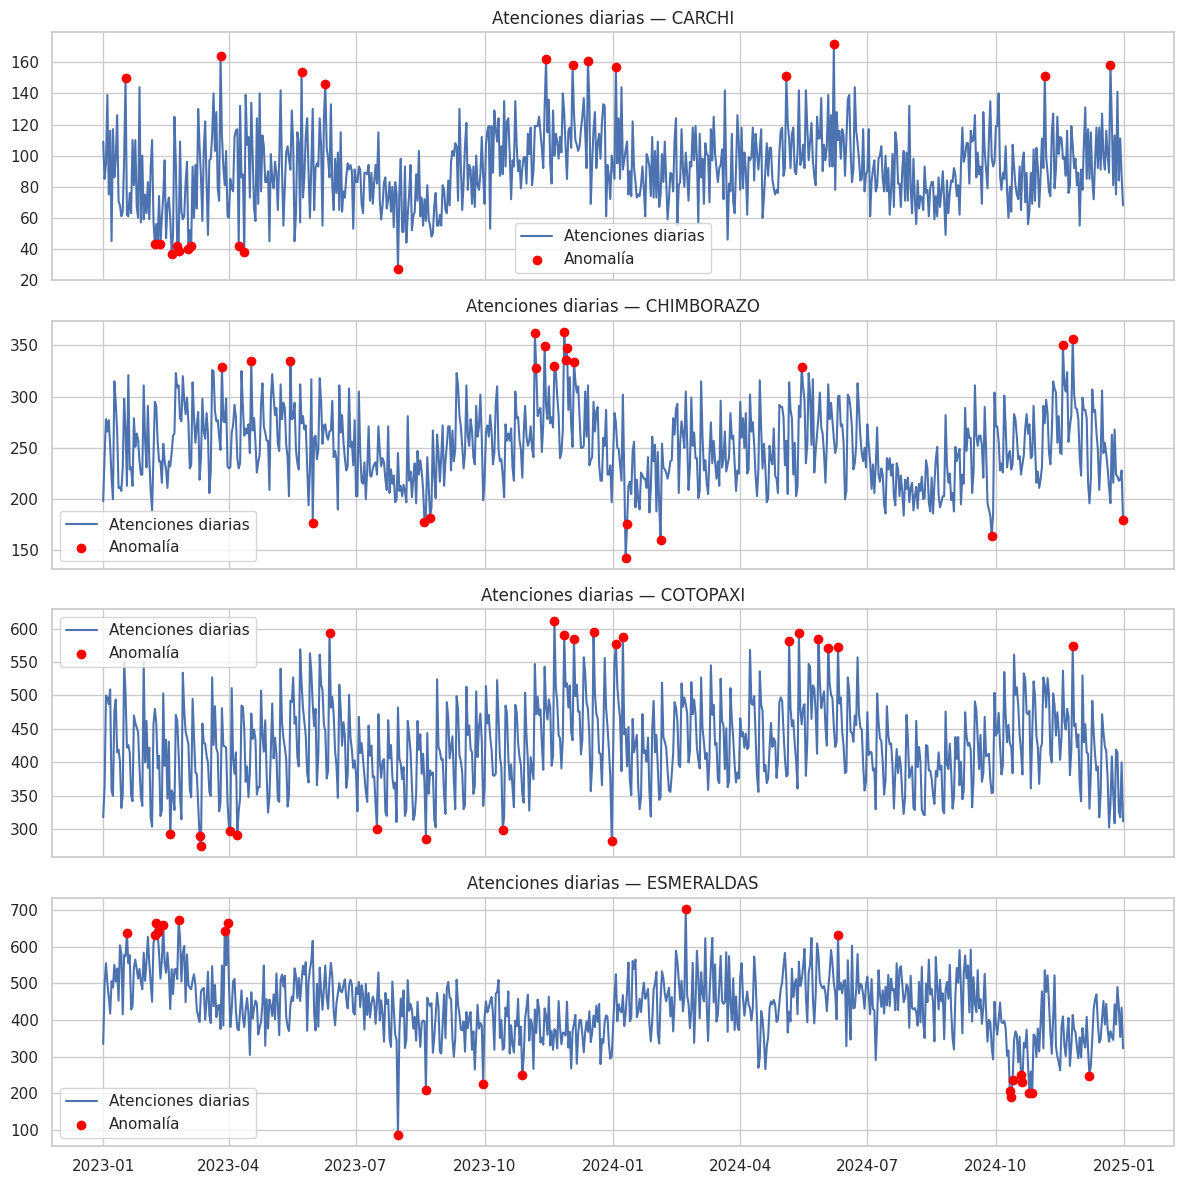

In [18]:
# 6.3 Visualizar anomalías para las provincias con más casos anómalos
provincias_con_mas_anomalias = anomalias["PROVINCIA"].value_counts().head(4).index

fig, axes = plt.subplots(len(provincias_con_mas_anomalias), 1, figsize=(12, 3 * len(provincias_con_mas_anomalias)), sharex=True)

for ax, provincia in zip(axes, provincias_con_mas_anomalias):
    datos_prov = serie_con_anomalias[serie_con_anomalias["PROVINCIA"] == provincia]
    ax.plot(datos_prov["fecha"], datos_prov["atenciones_dia"], color="#4C72B0", label="Atenciones diarias")
    anom_prov = datos_prov[datos_prov["anomalia"] == -1]
    ax.scatter(anom_prov["fecha"], anom_prov["atenciones_dia"], color="red", zorder=5, label="Anomalía")
    ax.set_title(f"Atenciones diarias — {provincia}")
    ax.legend()

plt.tight_layout()
plt.savefig("output_anomalias_provincias.png", dpi=150)
plt.show()


### 6.4 Relación con clima

Cruza las fechas marcadas como anomalía contra `dim_clima` para revisar si coinciden con precipitación o temperatura fuera de lo habitual — esto conecta el hallazgo de anomalías con la hipótesis central del proyecto (relación clima-enfermedad).


In [19]:
# 6.4 Cruce de anomalías con clima 
anomalias_clima = anomalias.merge(
    df[["PROVINCIA", "fecha","temperatura_promedio","lluvia_total_mm","condicion_clima"]].drop_duplicates(),
    on=["PROVINCIA", "fecha"],
    how="left"
)

anomalias_clima[["PROVINCIA", "fecha", "atenciones_dia","temperatura_promedio","lluvia_total_mm","condicion_clima"]].sort_values("atenciones_dia",ascending=False).head(20)


,PROVINCIA,fecha,atenciones_dia,temperatura_promedio,lluvia_total_mm,condicion_clima
112,MANABI,2024-01-03,2205,24.9,11.9,Lluvia Ligera
114,MANABI,2024-01-08,2177,25.4,13.6,Lluvia Moderada
113,MANABI,2024-01-04,2121,25.2,16.4,Lluvia Moderada
118,MANABI,2024-01-29,2074,26.1,8.3,Lluvia Moderada
116,MANABI,2024-01-15,2067,25.6,12.4,Lluvia Moderada
117,MANABI,2024-01-20,1506,25.4,13.9,Lluvia Moderada
115,MANABI,2024-01-10,1496,25.3,6.2,Lluvia Moderada
78,ESMERALDAS,2024-02-22,703,25.7,6.2,Lluvia Ligera
230,TUNGURAHUA,2023-01-16,700,12.7,0.8,Llovizna Ligera
233,TUNGURAHUA,2023-11-06,673,14.3,1.4,Llovizna Ligera


## 7. Uso de Redis/Valkey como caché de lookup (arquitectura del proyecto)

Redis/Valkey se documentó como capa de caché externa al pipeline KNIME, para consultas rápidas código→nombre de enfermedad.

In [20]:
import redis

r = redis.Redis(host="localhost", port=6379, db=0, decode_responses=True)

def nombre_diagnostico(codigo_cie10: str) -> str:
    datos = r.hgetall(f"cie10:{codigo_cie10}")
    return datos.get("nombre", "No encontrado en caché")

# Ejemplo de los códigos más frecuentes detectados en el EDA
for codigo in df["CIE"].value_counts().head(5).index:
    print(codigo, "->", nombre_diagnostico(codigo))


J00X -> No encontrado en caché
J039 -> Amigdalitis aguda, no especificada
J029 -> Faringitis aguda, no especificada
N390 -> Infección de vías urinarias, sitio no especificado
R104 -> Otros dolores abdominales y los no especificados


## 8. Resumen de hallazgos

**Volumen general**
- Total de atenciones de emergencia analizadas (2023-2024): `1,924,907`.

**Distribución por provincia**
- Provincia con mayor volumen de atenciones: `Esmeraldas` (320,250), seguida muy de cerca por `Tungurahua` (318,021) y `Cotopaxi` (310,836) — las tres concentran un volumen similar.
- A partir de `Chimborazo` (183,502) el volumen cae de forma marcada, y sigue descendiendo hasta `Santo Domingo de los Tsáchilas` (10,619), la de menor volumen del top registrado.

**Diagnósticos más frecuentes**
- `Amigdalitis aguda, no especificada` es el diagnóstico más frecuente con 123,824 atenciones (~6.4% del total).
- Le siguen `Faringitis aguda, no especificada` (89,832) e `Infección de vías urinarias, sitio no especificado` (68,473).
- Los tres diagnósticos más comunes son de tipo respiratorio o urinario, y concentran juntos cerca del 15% de todas las atenciones registradas.

**Tendencia temporal**
- Se observa un pico atípico en `enero de 2024` (138,888 atenciones) muy por encima de `enero de 2023` (82,704), un incremento de ~68%.
- El resto de los meses de 2024 tiende a estar por debajo de sus equivalentes en 2023 (con la excepción de mayo, prácticamente igual).
- A pesar del pico de enero, el total anual es similar entre ambos años (~960,130 en 2023 vs ~964,777 en 2024).

**Distribución por sexo y grupo etario**
- `Mujeres`: 1,135,455 atenciones (59%); `Hombres`: 789,427 (41%); `Intersexual`: 25 casos.
- El grupo etario más atendido es `19-30 años` (458,142), seguido de `31-45 años` (358,353); los extremos de edad (`0-5` y `76+`) representan volúmenes bastante menores.

**Calidad de los datos (pipeline ETL de KNIME)**
- 20.14% de las filas de `fact_emergencias` no tienen correspondencia en `dim_cie10` (diagnóstico huérfano), y 0.21% no tienen correspondencia en `dim_fecha`.
- Se detectaron 16,628 duplicados exactos y 186,036 duplicados por llave natural (fecha, diagnóstico, provincia, edad, sexo).
- 3,985 registros tienen fecha faltante o fuera del rango 2023-2024.
- Estos hallazgos sugieren revisar el pipeline ETL antes de tomar los resultados como definitivos, ya que podrían estar sesgando ligeramente las cifras anteriores.

**Detección de anomalías (Isolation Forest)**
- Se marcaron 253 de 8,392 combinaciones provincia-día como anómalas (~3%, según el parámetro de contaminación usado).
- Las anomalías más extremas se concentran en `Manabí` en enero de 2024 (coincidiendo con el pico general de ese mes), seguidas de casos en `Esmeraldas` y `Tungurahua`.

**Relación observada entre anomalías y variables climáticas**
- Las anomalías son mayormente días en los que el número de atenciones es significativamente mayor o menor que el comportamiento habitual de cada provincia. Al relacionar los registros con las variables climáticas vemos que varias anomalías coinciden con episodios de lluvia moderada o fuerte, mientras que otras coinciden con lluvias ligeras o lloviznas, por lo que no hay una relación única entre el clima y el incremento de atenciones. Eso indica que las condiciones climáticas podrían influir en algunos casos, pero que también existen otros factores que influyen.
